# Risk Prediction Pipeline
This notebook contains the advanced ML models (GBM, RF, LSTM) from the core inference engine to evaluate `bridge_fused.csv` and emit operational Risk Scores.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.ensemble import GradientBoostingClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, mean_squared_error
import joblib
import warnings
warnings.filterwarnings('ignore')
plt.style.use('dark_background')
PALETTE = ['#00D4FF', '#FF6B35', '#7FFF00', '#FFD700', '#FF69B4', '#9B59B6']
sns.set_palette(PALETTE)
SEED = 42
EXCLUDE = ['Timestamp', 'Maintenance_Alert', 'Vibration_Anomaly_Location', 'Localized_Strain_Hotspot', 'SHI_Predicted_24h_Ahead', 'SHI_Predicted_7d_Ahead', 'SHI_Predicted_30d_Ahead', 'Bridge_Mood_Meter']
ANOMALY_FEATURES = ['Vibration_ms2', 'Strain_microstrain', 'Deflection_mm', 'Displacement_mm', 'Modal_Frequency_Hz', 'Temperature_C', 'Wind_Speed_ms', 'Crack_Propagation_mm']
ae_threshold = 0.5  # Passed from analysis


In [2]:
# Load fused dataset generated from Analysis.ipynb
try:
    fused = pd.read_csv('bridge_fused.csv', parse_dates=['Timestamp'])
    fused_anom = pd.read_csv('bridge_fused_with_anomalies.csv', index_col=0)
    print(f'Loaded fused data: {fused.shape}')
except Exception as e:
    print('Could not load fused data. Ensure Analysis.ipynb has run.', e)


Loaded fused data: (43200, 72)


## 6. Risk Prediction Models

In [3]:
# ─── 6a. Prepare ML-ready feature matrix ─────────────────────────────────────

# Add anomaly features to main dataset
fused_ml = fused.copy()
if 'IF_label' in fused_anom.columns:
    fused_ml = fused_ml.join(
        fused_anom[['IF_label','IF_score','AE_recon_error','consensus_anomaly']],
        how='left'
    )
    fused_ml['IF_label'] = fused_ml['IF_label'].fillna(1)
    fused_ml['IF_score'] = fused_ml['IF_score'].fillna(0)
    fused_ml['AE_recon_error'] = fused_ml['AE_recon_error'].fillna(0)

# Full feature list (now includes anomaly scores)
ml_features = [c for c in fused_ml.select_dtypes(include=[np.number]).columns
               if c not in EXCLUDE 
               and c not in ['Probability_of_Failure_PoF', 'Structural_Health_Index_SHI',
                              'SHI_Predicted_24h_Ahead','SHI_Predicted_7d_Ahead','SHI_Predicted_30d_Ahead']]

X = fused_ml[ml_features].select_dtypes(include=[np.number]).fillna(0).values
y_pof = fused_ml['Probability_of_Failure_PoF'].fillna(0).values  # regression
y_shi = fused_ml['Structural_Health_Index_SHI'].fillna(50).values  # regression

# Binary risk: PoF > 0.3 → high risk
y_risk = (y_pof > 0.3).astype(int)

scaler_ml = StandardScaler()
X_scaled = scaler_ml.fit_transform(X)

X_tr, X_te, y_pof_tr, y_pof_te, y_shi_tr, y_shi_te, y_risk_tr, y_risk_te = train_test_split(
    X_scaled, y_pof, y_shi, y_risk, test_size=0.2, random_state=SEED, stratify=y_risk
)
print(f'Train: {X_tr.shape[0]} | Test: {X_te.shape[0]}')
print(f'High-risk samples (train): {y_risk_tr.sum()} / {len(y_risk_tr)}')

Train: 34560 | Test: 8640
High-risk samples (train): 7 / 34560


=== GBM Risk Classifier ===
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00      8638
   High Risk       1.00      0.50      0.67         2

    accuracy                           1.00      8640
   macro avg       1.00      0.75      0.83      8640
weighted avg       1.00      1.00      1.00      8640

ROC-AUC: 1.0000


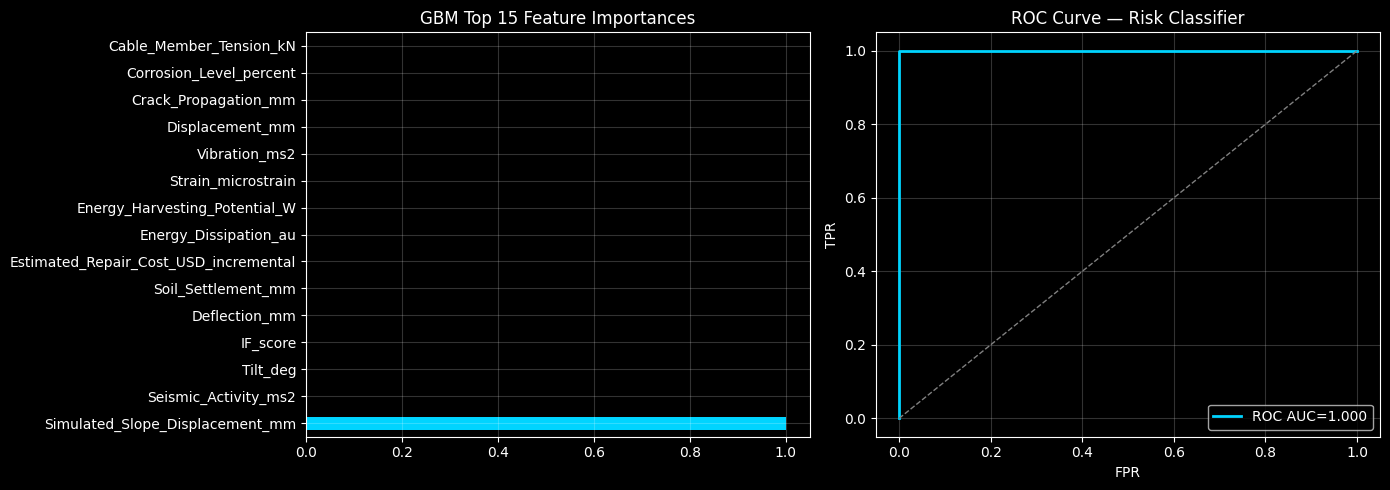

✅ GBM saved


In [4]:
# 6b. Gradient Boosting — Risk Classification 

gbm = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=SEED
)
gbm.fit(X_tr, y_risk_tr)
y_pred_risk = gbm.predict(X_te)
y_prob_risk = gbm.predict_proba(X_te)[:,1]

print('=== GBM Risk Classifier ===')
print(classification_report(y_risk_te, y_pred_risk, target_names=['Low Risk','High Risk']))
print(f'ROC-AUC: {roc_auc_score(y_risk_te, y_prob_risk):.4f}')

# Feature importance
feat_importance = pd.Series(gbm.feature_importances_, index=ml_features[:X.shape[1]]).nlargest(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

feat_importance.plot(kind='barh', ax=axes[0], color=PALETTE[0])
axes[0].set_title('GBM Top 15 Feature Importances')
axes[0].grid(alpha=0.2)

# ROC curve
fpr, tpr, _ = roc_curve(y_risk_te, y_prob_risk)
axes[1].plot(fpr, tpr, color=PALETTE[0], linewidth=2, 
             label=f'ROC AUC={roc_auc_score(y_risk_te, y_prob_risk):.3f}')
axes[1].plot([0,1],[0,1], '--', color='gray', linewidth=1)
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve — Risk Classifier')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('figures/gbm_risk.png', dpi=150, bbox_inches='tight')
plt.show()

joblib.dump(gbm, 'models/gbm_risk_classifier.pkl')
joblib.dump(scaler_ml, 'models/scaler_ml.pkl')
print('✅ GBM saved')

=== GBM Risk Classifier ===
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00      8638
   High Risk       1.00      0.50      0.67         2

    accuracy                           1.00      8640
   macro avg       1.00      0.75      0.83      8640
weighted avg       1.00      1.00      1.00      8640

ROC-AUC: 1.0000


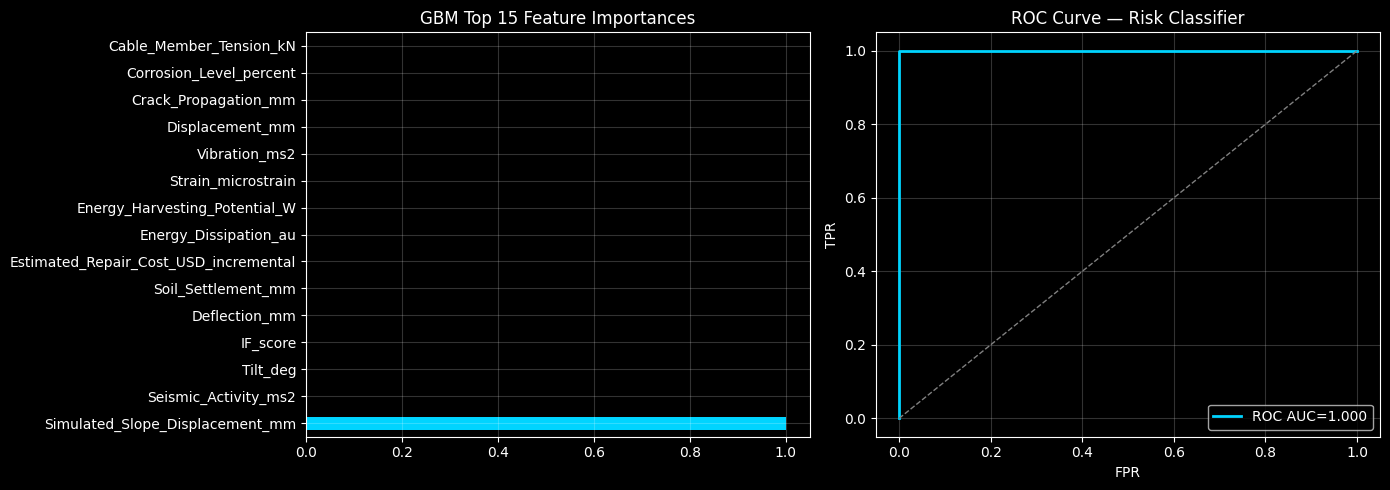

✅ GBM saved


In [5]:
# ─── 6b. Gradient Boosting — Risk Classification ──────────────────────────────

gbm = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=SEED
)
gbm.fit(X_tr, y_risk_tr)
y_pred_risk = gbm.predict(X_te)
y_prob_risk = gbm.predict_proba(X_te)[:,1]

print('=== GBM Risk Classifier ===')
print(classification_report(y_risk_te, y_pred_risk, target_names=['Low Risk','High Risk']))
print(f'ROC-AUC: {roc_auc_score(y_risk_te, y_prob_risk):.4f}')

# Feature importance
feat_importance = pd.Series(gbm.feature_importances_, index=ml_features[:X.shape[1]]).nlargest(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

feat_importance.plot(kind='barh', ax=axes[0], color=PALETTE[0])
axes[0].set_title('GBM Top 15 Feature Importances')
axes[0].grid(alpha=0.2)

# ROC curve
fpr, tpr, _ = roc_curve(y_risk_te, y_prob_risk)
axes[1].plot(fpr, tpr, color=PALETTE[0], linewidth=2, 
             label=f'ROC AUC={roc_auc_score(y_risk_te, y_prob_risk):.3f}')
axes[1].plot([0,1],[0,1], '--', color='gray', linewidth=1)
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve — Risk Classifier')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('figures/gbm_risk.png', dpi=150, bbox_inches='tight')
plt.show()

joblib.dump(gbm, 'models/gbm_risk_classifier.pkl')
joblib.dump(scaler_ml, 'models/scaler_ml.pkl')
print('✅ GBM saved')

SHI Prediction RMSE: 0.005


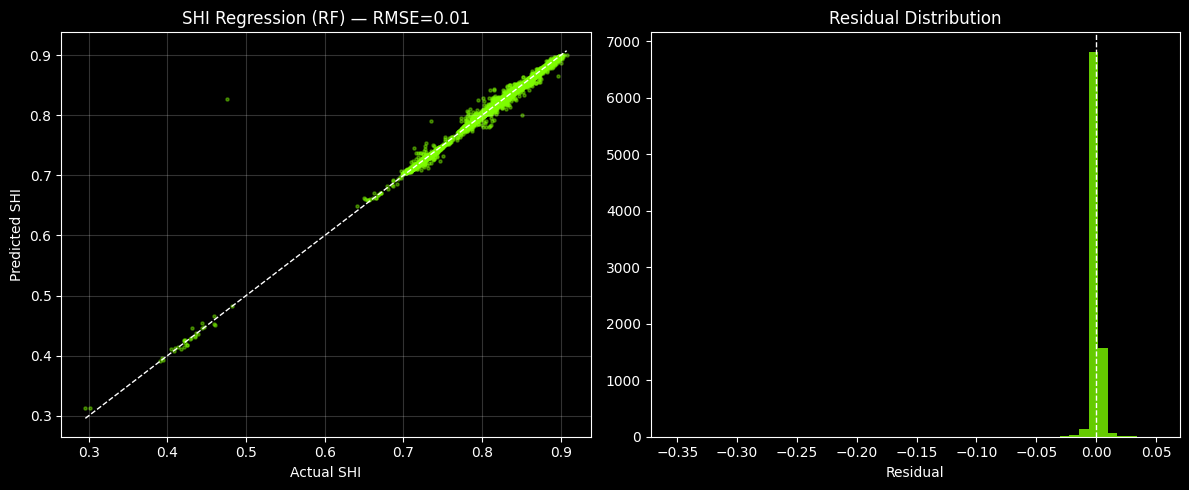

✅ RF SHI Regressor saved


In [ ]:
# ─── 6c. Random Forest — SHI Regression ───────────────────────────────────────

rf_shi = RandomForestRegressor(
    n_estimators=200, max_depth=10, min_samples_leaf=5,
    random_state=SEED, n_jobs=-1
)
rf_shi.fit(X_tr, y_shi_tr)
y_pred_shi = rf_shi.predict(X_te)

rmse_shi = np.sqrt(mean_squared_error(y_shi_te, y_pred_shi))
print(f'SHI Prediction RMSE: {rmse_shi:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_shi_te, y_pred_shi, s=5, alpha=0.4, color=PALETTE[2])
mn, mx = y_shi_te.min(), y_shi_te.max()
axes[0].plot([mn,mx],[mn,mx], '--', color='white', linewidth=1)
axes[0].set_xlabel('Actual SHI')
axes[0].set_ylabel('Predicted SHI')
axes[0].set_title(f'SHI Regression (RF) — RMSE={rmse_shi:.2f}')
axes[0].grid(alpha=0.2)

residuals = y_shi_te - y_pred_shi
axes[1].hist(residuals, bins=50, color=PALETTE[2], alpha=0.8)
axes[1].axvline(0, color='white', linestyle='--', linewidth=1)
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.savefig('figures/rf_shi_regression.png', dpi=150, bbox_inches='tight')
plt.show()

joblib.dump(rf_shi, 'models/rf_shi_regressor.pkl')
print('RF SHI Regressor saved')

In [ ]:
# ─── 6d. LSTM — Temporal Risk Prediction ──────────────────────────────────────
#  Sequence model: predict PoF at t+1 from past WINDOW_SIZE steps

WINDOW_SIZE = 24   # look-back window
STEP        = 1

def build_sequences(X, y, window_size, step=1):
    Xs, ys = [], []
    for i in range(0, len(X) - window_size, step):
        Xs.append(X[i:i+window_size])
        ys.append(y[i+window_size])
    return np.array(Xs), np.array(ys)

# Use full scaled data (preserve temporal order)
X_seq, y_seq = build_sequences(X_scaled, y_pof, WINDOW_SIZE, STEP)
split = int(0.8 * len(X_seq))
X_seq_tr, X_seq_te = X_seq[:split], X_seq[split:]
y_seq_tr, y_seq_te = y_seq[:split], y_seq[split:]

print(f'LSTM sequences — Train: {X_seq_tr.shape}, Test: {X_seq_te.shape}')

class LSTMRiskPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1),
            nn.Sigmoid()  # output PoF in [0,1]
        )
    
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze()

def train_lstm(X_tr, y_tr, X_te, y_te, epochs=30, batch_size=128, lr=1e-3):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    tr_ds = TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr))
    te_ds = TensorDataset(torch.FloatTensor(X_te), torch.FloatTensor(y_te))
    tr_ld = DataLoader(tr_ds, batch_size=batch_size, shuffle=False)
    te_ld = DataLoader(te_ds, batch_size=batch_size, shuffle=False)
    
    model = LSTMRiskPredictor(X_tr.shape[2], hidden_dim=64, num_layers=2).to(device)
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    crit  = nn.MSELoss()
    
    tr_losses, te_losses = [], []
    for epoch in range(epochs):
        model.train()
        tr_loss = 0
        for Xb, yb in tr_ld:
            Xb, yb = Xb.to(device), yb.to(device)
            optim.zero_grad()
            out = model(Xb)
            loss = crit(out, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim.step()
            tr_loss += loss.item()
        
        model.eval()
        te_loss = 0
        with torch.no_grad():
            for Xb, yb in te_ld:
                Xb, yb = Xb.to(device), yb.to(device)
                te_loss += crit(model(Xb), yb).item()
        
        tr_losses.append(tr_loss/len(tr_ld))
        te_losses.append(te_loss/len(te_ld))
        if (epoch+1) % 5 == 0:
            print(f'Epoch {epoch+1:3d} | Train: {tr_losses[-1]:.5f} | Val: {te_losses[-1]:.5f}')
    
    return model, tr_losses, te_losses, device

lstm_model, lstm_tr_loss, lstm_te_loss, device = train_lstm(
    X_seq_tr, y_seq_tr, X_seq_te, y_seq_te, epochs=30
)
torch.save(lstm_model.state_dict(), 'models/lstm_risk.pt')
print('LSTM saved')

LSTM sequences — Train: (34540, 24, 65), Test: (8636, 24, 65)


Epoch   5 | Train: 0.00018 | Val: 0.00027


Epoch  10 | Train: 0.00012 | Val: 0.00026


Epoch  15 | Train: 0.00012 | Val: 0.00026


Epoch  20 | Train: 0.00013 | Val: 0.00026


Epoch  25 | Train: 0.00012 | Val: 0.00029


Epoch  30 | Train: 0.00010 | Val: 0.00026
✅ LSTM saved


LSTM PoF RMSE: 0.0161


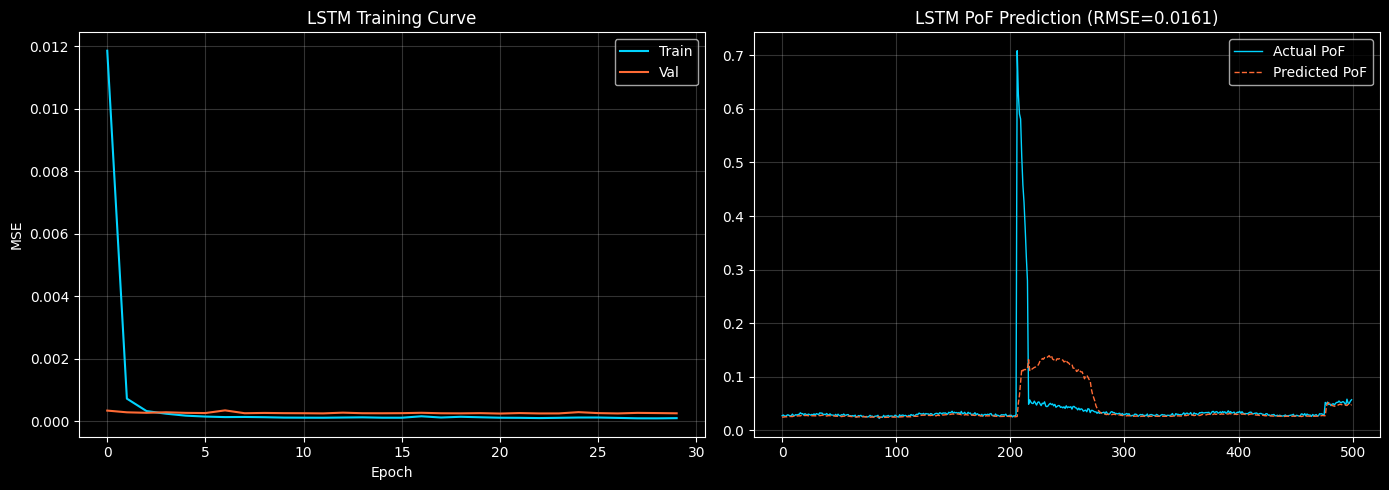

In [8]:
# ─── LSTM evaluation ──────────────────────────────────────────────────────────
lstm_model.eval()
with torch.no_grad():
    X_te_t = torch.FloatTensor(X_seq_te).to(device)
    y_pred_pof = lstm_model(X_te_t).cpu().numpy()

rmse_pof = np.sqrt(mean_squared_error(y_seq_te, y_pred_pof))
print(f'LSTM PoF RMSE: {rmse_pof:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training curve
axes[0].plot(lstm_tr_loss, label='Train', color=PALETTE[0])
axes[0].plot(lstm_te_loss, label='Val',   color=PALETTE[1])
axes[0].set_title('LSTM Training Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(alpha=0.2)

# Prediction vs actual
n_show = min(500, len(y_seq_te))
axes[1].plot(y_seq_te[:n_show], label='Actual PoF', color=PALETTE[0], linewidth=1)
axes[1].plot(y_pred_pof[:n_show], label='Predicted PoF', color=PALETTE[1], linewidth=1, linestyle='--')
axes[1].set_title(f'LSTM PoF Prediction (RMSE={rmse_pof:.4f})')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('figures/lstm_pof.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Risk Scoring Profile & Summary Export

Risk Tier Distribution:
risk_tier
Low         42998
Medium        193
High            8
Critical        1
Name: count, dtype: int64


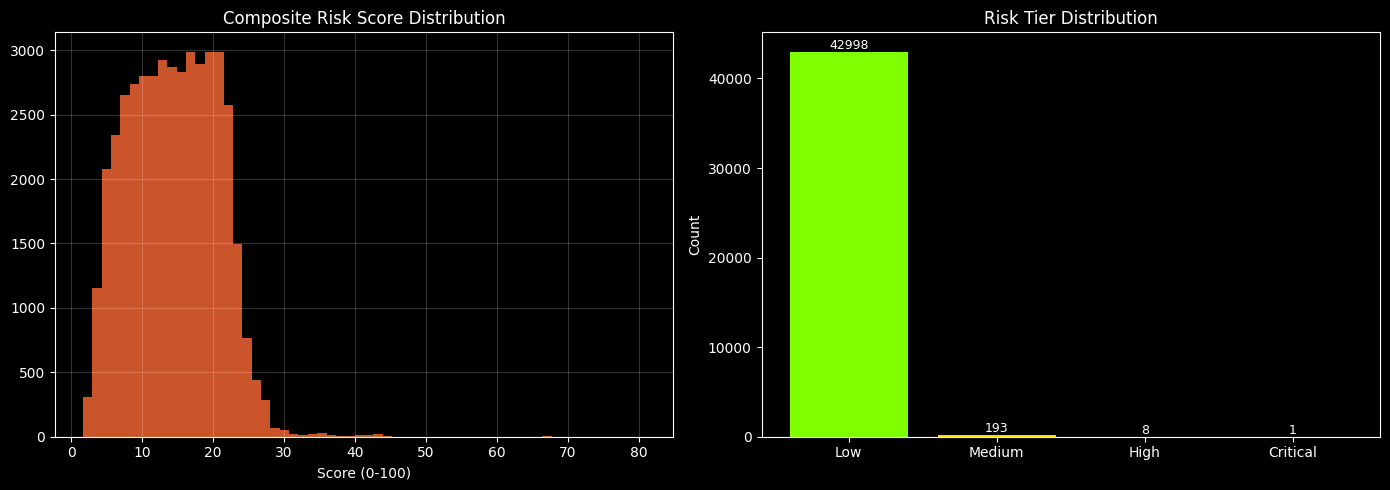

In [9]:
# ─── Composite Risk Score ─────────────────────────────────────────────────────
# Weighted combination of multiple risk signals

def compute_composite_risk(df):
    """
    Composite risk score (0-100) from multi-source signals.
    Higher = more critical.
    """
    risk = pd.Series(np.zeros(len(df)), index=df.index)
    
    def normalized(col, invert=False):
        if col not in df.columns:
            return 0
        s = df[col].fillna(df[col].median())
        n = (s - s.min()) / (s.max() - s.min() + 1e-9)
        return (1 - n) if invert else n
    
    weights = {
        'Probability_of_Failure_PoF':  0.30,
        'Structural_Health_Index_SHI': 0.20,  # inverted
        'Crack_Propagation_mm':        0.15,
        'Corrosion_Level_percent':     0.10,
        'Fatigue_Accumulation_au':     0.10,
        'Anomaly_Detection_Score':     0.10,
        'Vibration_ms2':               0.05,
    }
    
    for col, w in weights.items():
        invert = col == 'Structural_Health_Index_SHI'
        risk += w * normalized(col, invert=invert)
    
    return (risk * 100).clip(0, 100)

fused_ml['composite_risk_score'] = compute_composite_risk(fused_ml)

# Risk tier
fused_ml['risk_tier'] = pd.cut(
    fused_ml['composite_risk_score'],
    bins=[0, 30, 60, 80, 100],
    labels=['Low', 'Medium', 'High', 'Critical']
)

print('Risk Tier Distribution:')
print(fused_ml['risk_tier'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fused_ml['composite_risk_score'].hist(bins=60, ax=axes[0], color=PALETTE[1], alpha=0.8)
axes[0].set_title('Composite Risk Score Distribution')
axes[0].set_xlabel('Score (0-100)')
axes[0].grid(alpha=0.2)

tier_counts = fused_ml['risk_tier'].value_counts().reindex(['Low','Medium','High','Critical'])
bars = axes[1].bar(tier_counts.index, tier_counts.values, 
                    color=['#7FFF00','#FFD700','#FF6B35','#FF1493'])
axes[1].set_title('Risk Tier Distribution')
axes[1].set_ylabel('Count')
for bar, val in zip(bars, tier_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figures/risk_profile.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Save final processed dataset & model metadata

fused_ml.to_csv('bridge_final_processed.csv', index=False)

model_meta = {
    'feature_columns': ml_features,
    'anomaly_features': ANOMALY_FEATURES,
    'window_size_lstm': WINDOW_SIZE,
    'ae_threshold': float(ae_threshold),
    'risk_weights': {
        'Probability_of_Failure_PoF': 0.30,
        'Structural_Health_Index_SHI': 0.20,
        'Crack_Propagation_mm': 0.15,
        'Corrosion_Level_percent': 0.10,
        'Fatigue_Accumulation_au': 0.10,
        'Anomaly_Detection_Score': 0.10,
        'Vibration_ms2': 0.05,
    }
}

import json
with open('models/model_meta.json', 'w') as f:
    json.dump(model_meta, f, indent=2)

print('=== Pipeline Summary ===')
print(f'✅ Fused dataset:        bridge_final_processed.csv ({fused_ml.shape})')
print(f'✅ Isolation Forest:     models/isolation_forest.pkl')
print(f'✅ Autoencoder:          models/autoencoder.pt')
print(f'✅ GBM Risk Classifier:  models/gbm_risk_classifier.pkl')
print(f'✅ RF SHI Regressor:     models/rf_shi_regressor.pkl')
print(f'✅ LSTM PoF Predictor:   models/lstm_risk.pt')
print(f'✅ Model metadata:       models/model_meta.json')
print(f'✅ All figures:          figures/')

=== Pipeline Summary ===
✅ Fused dataset:        bridge_final_processed.csv ((43200, 78))
✅ Isolation Forest:     models/isolation_forest.pkl
✅ Autoencoder:          models/autoencoder.pt
✅ GBM Risk Classifier:  models/gbm_risk_classifier.pkl
✅ RF SHI Regressor:     models/rf_shi_regressor.pkl
✅ LSTM PoF Predictor:   models/lstm_risk.pt
✅ Model metadata:       models/model_meta.json
✅ All figures:          figures/


## 9. Quick Inference Test (model serving preview)

In [11]:
# Inference pipeline for the Agentic API 

def predict_risk_for_record(record: dict) -> dict:
    """
    Given a flat dict of sensor readings, return:
    - composite_risk_score (0-100)
    - risk_tier
    - anomaly_flag (IF)
    - pof (GBM probability)
    - shi_predicted (RF)
    """
    # Load models
    _iso    = joblib.load('models/isolation_forest.pkl')
    _sc_an  = joblib.load('models/scaler_anomaly.pkl')
    _gbm    = joblib.load('models/gbm_risk_classifier.pkl')
    _rf_shi = joblib.load('models/rf_shi_regressor.pkl')
    _sc_ml  = joblib.load('models/scaler_ml.pkl')
    
    # Anomaly check - replace NaN with 0
    anom_vals = np.array([[record.get(f, 0.0) for f in ANOMALY_FEATURES]])
    anom_vals = np.nan_to_num(anom_vals, nan=0.0)
    anom_scaled = _sc_an.transform(anom_vals)
    anomaly_flag = _iso.predict(anom_scaled)[0] == -1
    
    # Risk & SHI prediction - replace NaN with 0
    feat_vals = np.array([[record.get(f, 0.0) for f in ml_features[:X.shape[1]]]])
    feat_vals = np.nan_to_num(feat_vals, nan=0.0)
    feat_scaled = _sc_ml.transform(feat_vals)
    pof_prob    = _gbm.predict_proba(feat_scaled)[0][1]
    shi_pred    = _rf_shi.predict(feat_scaled)[0]
    
    # Simple composite risk from record - handle NaN values
    comp_risk = min(100, max(0,
        30 * float(np.nan_to_num(record.get('Probability_of_Failure_PoF', 0), nan=0.0)) +
        20 * (1 - float(np.nan_to_num(record.get('Structural_Health_Index_SHI', 50), nan=50.0)) / 100) +
        15 * min(1, float(np.nan_to_num(record.get('Crack_Propagation_mm', 0), nan=0.0)) / 5) +
        10 * float(np.nan_to_num(record.get('Corrosion_Level_percent', 0), nan=0.0)) / 100 +
        10 * min(1, float(np.nan_to_num(record.get('Fatigue_Accumulation_au', 0), nan=0.0))) +
        15 * float(anomaly_flag)
    ) * 100)
    
    tier = 'Low' if comp_risk < 30 else 'Medium' if comp_risk < 60 else 'High' if comp_risk < 80 else 'Critical'
    
    return {
        'composite_risk_score': round(comp_risk, 2),
        'risk_tier': tier,
        'anomaly_flag': bool(anomaly_flag),
        'pof_probability': round(float(pof_prob), 4),
        'shi_predicted': round(float(shi_pred), 2)
    }

# Test with a sample record
sample = fused_ml.iloc[100].to_dict()
result = predict_risk_for_record(sample)
print('=== Sample Prediction ===')
for k, v in result.items():
    print(f'  {k}: {v}')
print('\n✅ Inference pipeline ready for API integration!')

=== Sample Prediction ===
  composite_risk_score: 100
  risk_tier: Critical
  anomaly_flag: False
  pof_probability: 0.0
  shi_predicted: 0.84

✅ Inference pipeline ready for API integration!
